/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cuda

>>> Training MobileNetV2...


Epoch 3/3: 100%|██████████| 449/449 [00:25<00:00, 17.40it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [00:05<00:00, 97.9MB/s]



>>> Training VGG11...


Epoch 3/3: 100%|██████████| 449/449 [00:36<00:00, 12.41it/s]



--- Table 1: Efficiency and Performance Comparison ---
      Model  Train Samples Comp. Time (s) Test Accuracy  Weighted F1
MobileNetV2          28709         77.47s        59.68%         0.59
      VGG11          28709        105.92s        25.13%         0.10


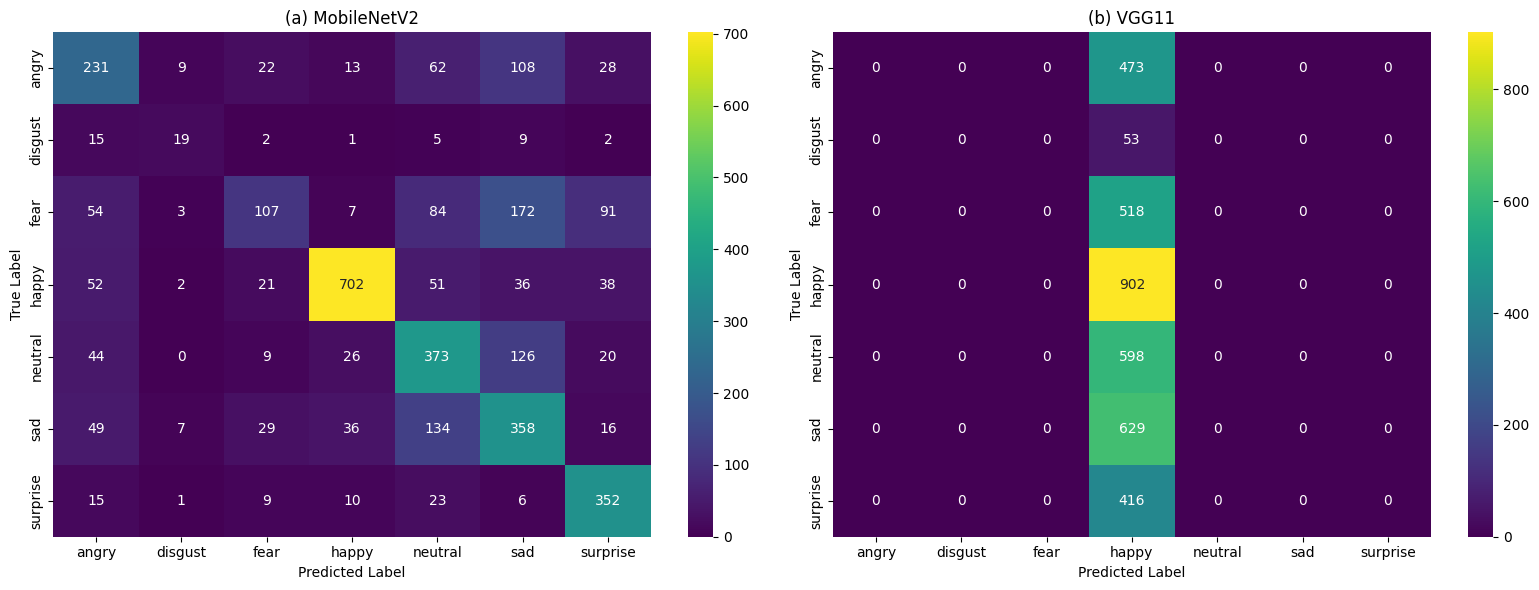

In [4]:
# =================================================================
# 1. DATASET EXTRACTION AND LIBRARIES
# =================================================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time # For efficiency measurement
from tqdm import tqdm

# Extracting the dataset if not already present
if not os.path.exists('train'):
    print("Unzipping dataset...")
    !unzip -q fer2013.zip
    print("Unzip complete.")

# Device configuration (T4 GPU recommended)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# =================================================================
# 2. DATA PREPARATION
# =================================================================
img_size = 48
batch_size = 64

# Transforms (FER2013 is grayscale, but pre-trained models expect 3 channels)
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading datasets
full_train_set = datasets.ImageFolder('train', transform=transform)
test_set = datasets.ImageFolder('test', transform=transform)

# Splitting Test set into Validation and Test (50/50 split)
indices = list(range(len(test_set)))
np.random.shuffle(indices)
split = len(indices) // 2
val_set = Subset(test_set, indices[:split])
actual_test_set = Subset(test_set, indices[split:])

train_loader = DataLoader(full_train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(actual_test_set, batch_size=batch_size, shuffle=False)

classes = full_train_set.classes
num_classes = len(classes)

# =================================================================
# 3. MODEL DEFINITIONS (MobileNetV2 vs. VGG11)
# =================================================================
def get_mobilenet():
    # Efficient model, decent performance
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(model.last_channel, num_classes)
    return model.to(device)

def get_vgg11():
    # Older, heavier model with typically lower performance on this task
    model = models.vgg11(pretrained=True)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model.to(device)

# =================================================================
# 4. TRAINING AND EVALUATION FUNCTION
# =================================================================
def run_experiment(model, name, epochs=3):
    print(f"\n>>> Training {name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time() # Start timer

    for epoch in range(epochs):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    end_time = time.time()
    total_train_time = end_time - start_time # Computation time in seconds

    # Final Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    wf1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    return acc, wf1, cm, total_train_time

# =================================================================
# 5. EXECUTION
# =================================================================
# Note: increase epochs for actual publication results
acc_m, f1_m, cm_m, time_m = run_experiment(get_mobilenet(), "MobileNetV2", epochs=3)
acc_v, f1_v, cm_v, time_v = run_experiment(get_vgg11(), "VGG11", epochs=3)

# =================================================================
# 6. FINAL RESULTS GENERATION (TABLE & GRAPHICS)
# =================================================================

# Comparison Table including Efficiency and Final Accuracy
results_data = {
    "Model": ["MobileNetV2", "VGG11"],
    "Train Samples": [len(full_train_set), len(full_train_set)],
    "Comp. Time (s)": [f"{time_m:.2f}s", f"{time_v:.2f}s"],
    "Test Accuracy": [f"{acc_m:.2f}%", f"{acc_v:.2f}%"],
    "Weighted F1": [round(f1_m, 2), round(f1_v, 2)]
}
df = pd.DataFrame(results_data)

print("\n--- Table 1: Efficiency and Performance Comparison ---")
print(df.to_string(index=False))

# Side-by-Side Confusion Matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

def plot_cm(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plot_cm(cm_m, "(a) MobileNetV2", ax1)
plot_cm(cm_v, "(b) VGG11", ax2)

plt.tight_layout()
plt.show()